# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 03 — Los modelos generativos

**Objetivo.** Entrenar los generadores que producirán las ventanas sintéticas y —antes de
usarlos— **auditarlos**. El enunciado solo exige medir el efecto *downstream*, pero sin esta
auditoría un generador que mejore el modelo por puro efecto regularizador sería
indistinguible de otro que lo mejore por realismo, y son conclusiones opuestas.

### Qué se genera exactamente

Se modela la distribución **conjunta** del par `[X | y]` (60 retornos + target), no `X` por
separado. Es la opción **OPT2** de las transparencias del profesor: `z → Generador → (Xg, yg)`.
Un generador que solo produjera `X` obligaría a etiquetar después, y esa etiqueta sería
inventada por otro modelo — contaminando el experimento en su punto más sensible.

### Los seis generadores

| # | Generador | Familia | Papel |
|---|---|---|---|
| 1 | Jitter | trivial | el "modelo simple" que pide el enunciado |
| 2 | Gaussiana multivariante | paramétrico | captura toda la dependencia **lineal**; el rival honesto |
| 3 | Block bootstrap estacionario | remuestreo | preserva colas y clustering *por construcción* |
| 4 | **VAE** | latente variacional | red 1 |
| 5 | **WGAN-GP** | adversarial | red 2 |
| 6 | **RealNVP** | flow biyectivo | red 3 — única con verosimilitud exacta |

Las tres familias neuronales cubren el requisito de "3 tipos distintos de modelo generativo";
las tres primeras son baselines que hacen la comparación honesta.

### Regla anti-fuga

Los generadores se ajustan **solo con el conjunto de train**. Ni validación ni test entran
jamás en un generador: si lo hicieran, los datos sintéticos transportarían información del
futuro al entrenamiento y todo el experimento quedaría invalidado.

## 0 · Setup

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.generators import (JitterGenerator, GaussianGenerator, BlockBootstrapGenerator,
                            VAEGenerator, WGANGPGenerator, RealNVPGenerator)
from src.gen_audit import audit_generator
from src.gen_utility import resumir_tstr, tstr_trtr
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
if device.type == "cpu":
    torch.set_num_threads(8)

d = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))

def to_XY(split):
    # Par conjunto [X | y] estandarizado con los estadísticos de train

    X = (d[f"X_{split}"] - std["x_mu"]) / std["x_sd"]
    y = (d[f"y_{split}"] - std["y_mu"]) / std["y_sd"]
    return np.column_stack([X, y]).astype(np.float32)

XY_train, XY_val = to_XY("train"), to_XY("val")
print("Device:", device, "| XY_train:", XY_train.shape, "| XY_val (solo auditoría):", XY_val.shape)

Device: cuda | XY_train: (102406, 61) | XY_val (solo auditoría): (17146, 61)


## 1 · Configuración de los generadores

Los hiperparámetros no salen de la nada: son el resultado de un ciclo de diagnóstico
documentado en §4. Dos merecen explicación explícita porque corrigen defectos reales que
aparecieron al auditar las primeras versiones:

* **VAE con ruido de observación.** El decoder devuelve `E[x|z]`, no una muestra de `p(x|z)`.
  Muestrear solo la media pierde el segundo término de
  `Var(x) = Var(E[x|z]) + E[Var(x|z)]`: las primeras muestras salían con desviación típica
  0,39 frente a 1,00 real. Reinyectamos la desviación residual estimada tras entrenar, que
  es exactamente el decoder gaussiano de varianza aprendida que el ELBO define.
* **WGAN-GP en lugar de GAN clásica.** La pérdida de una GAN vanilla oscila alrededor de un
  equilibrio y **no demuestra convergencia** — choca con el requisito del enunciado. La
  pérdida del crítico de WGAN-GP aproxima la distancia de Wasserstein: es decreciente e
  interpretable. Además necesita bastantes más épocas que el VAE porque el generador solo
  se actualiza 1 de cada `n_critic` pasos.

In [2]:
GENERADORES = {
    "jitter":          JitterGenerator(noise=0.10),
    "gaussiana":       GaussianGenerator(),
    "block_bootstrap": BlockBootstrapGenerator(mean_block=10),
    "vae":             VAEGenerator(latent=16, hidden=256, beta=1.0, epochs=40),
    "wgan_gp":         WGANGPGenerator(latent=32, hidden=256, epochs=150, lr=2e-4, n_critic=5),
    "realnvp":         RealNVPGenerator(n_layers=6, hidden=128, epochs=30),
}
NEURONALES = ["vae", "wgan_gp", "realnvp"]

fitted, tiempos = {}, {}
for name, gen in GENERADORES.items():
    t0 = time.time()
    gen.fit(XY_train, seed=cfg.seed) if name in NEURONALES else gen.fit(XY_train)
    tiempos[name] = time.time() - t0
    fitted[name] = gen
    print(f"{name:16s} ajustado en {tiempos[name]:7.1f}s")

jitter           ajustado en     0.0s
gaussiana        ajustado en     0.1s
block_bootstrap  ajustado en     0.0s


vae              ajustado en    49.0s


wgan_gp          ajustado en   169.3s


realnvp          ajustado en    80.5s


### 1.1 · Arquitectura de las tres familias neuronales

Antes de mirar sus curvas de loss, conviene ver qué son. Los tres diagramas se generan con
[PlotNeuralNet](https://github.com/HarisIqbal88/PlotNeuralNet) desde `src/netviz.py`, y —esto
es lo importante— **se derivan por introspección de los generadores que se acaban de
ajustar**, no de una descripción escrita a mano. A la celda se le pasa el diccionario
`fitted`, así que las cifras de cada figura son literalmente las de los objetos entrenados
en la celda anterior: si mañana se cambia `n_layers=6` por otro valor, el diagrama cambia
con él.

No es una precaución teórica. Las clases de `src/generators.py` traen por defecto
`RealNVPGenerator(n_layers=8, hidden=256)`, pero este notebook entrena con **6 capas y
hidden 128**; una figura dibujada "de memoria" a partir de la firma de la clase habría
inventado dos capas de acoplamiento inexistentes.

Lo que hay que leer en cada una:

* **VAE** — la bifurcación en μ y log σ² es la firma del modelo: el encoder no produce un
  código, produce una *distribución*. El cuello de 16 unidades frente a las 61 de entrada
  es el cuello de botella que fuerza el suavizado, y explica la curtosis 1,6 de §3.
* **WGAN-GP** — dos redes, no una. El crítico recibe ventanas reales y falsas y devuelve un
  escalar; no hay reconstrucción ni verosimilitud en ninguna parte, y de ahí que su curva
  solo pueda estabilizarse, no descender a un óptimo.
* **RealNVP** — la cadena de acoplamientos con máscaras alternas par/impar. El detalle de
  abajo muestra por qué el jacobiano es triangular y su log-determinante, una simple suma:
  es lo que hace la verosimilitud exacta y barata.

  = 20_arq_vae: sin cambios, se reutiliza el PNG cacheado


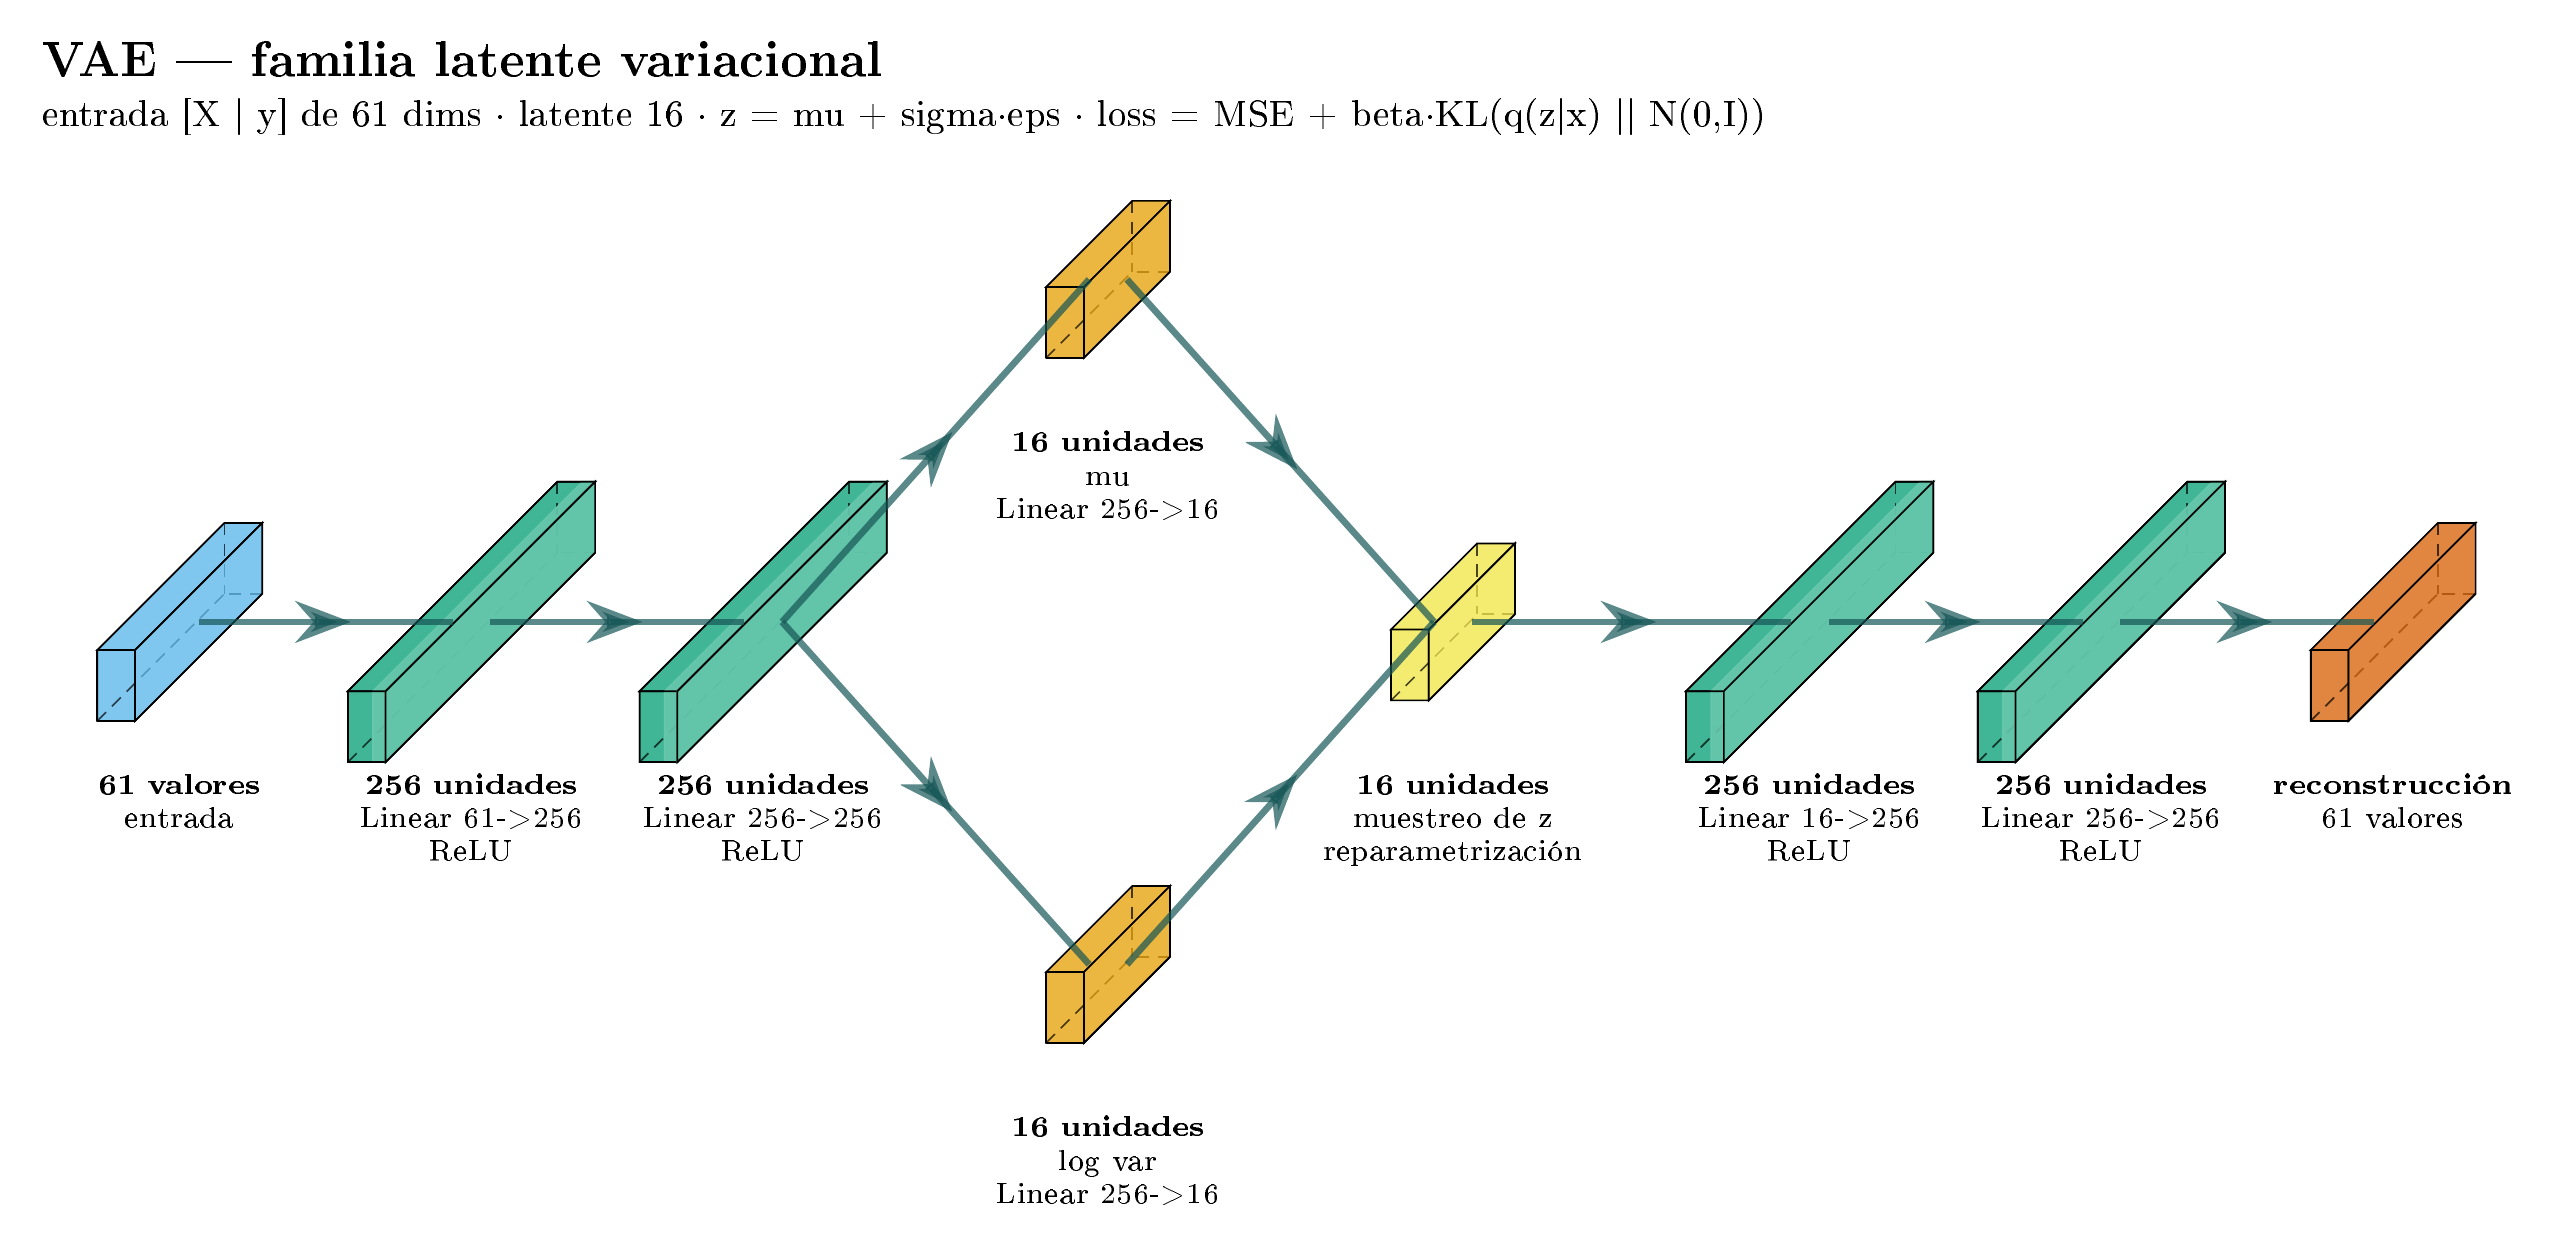

  = 21_arq_wgan_gp: sin cambios, se reutiliza el PNG cacheado


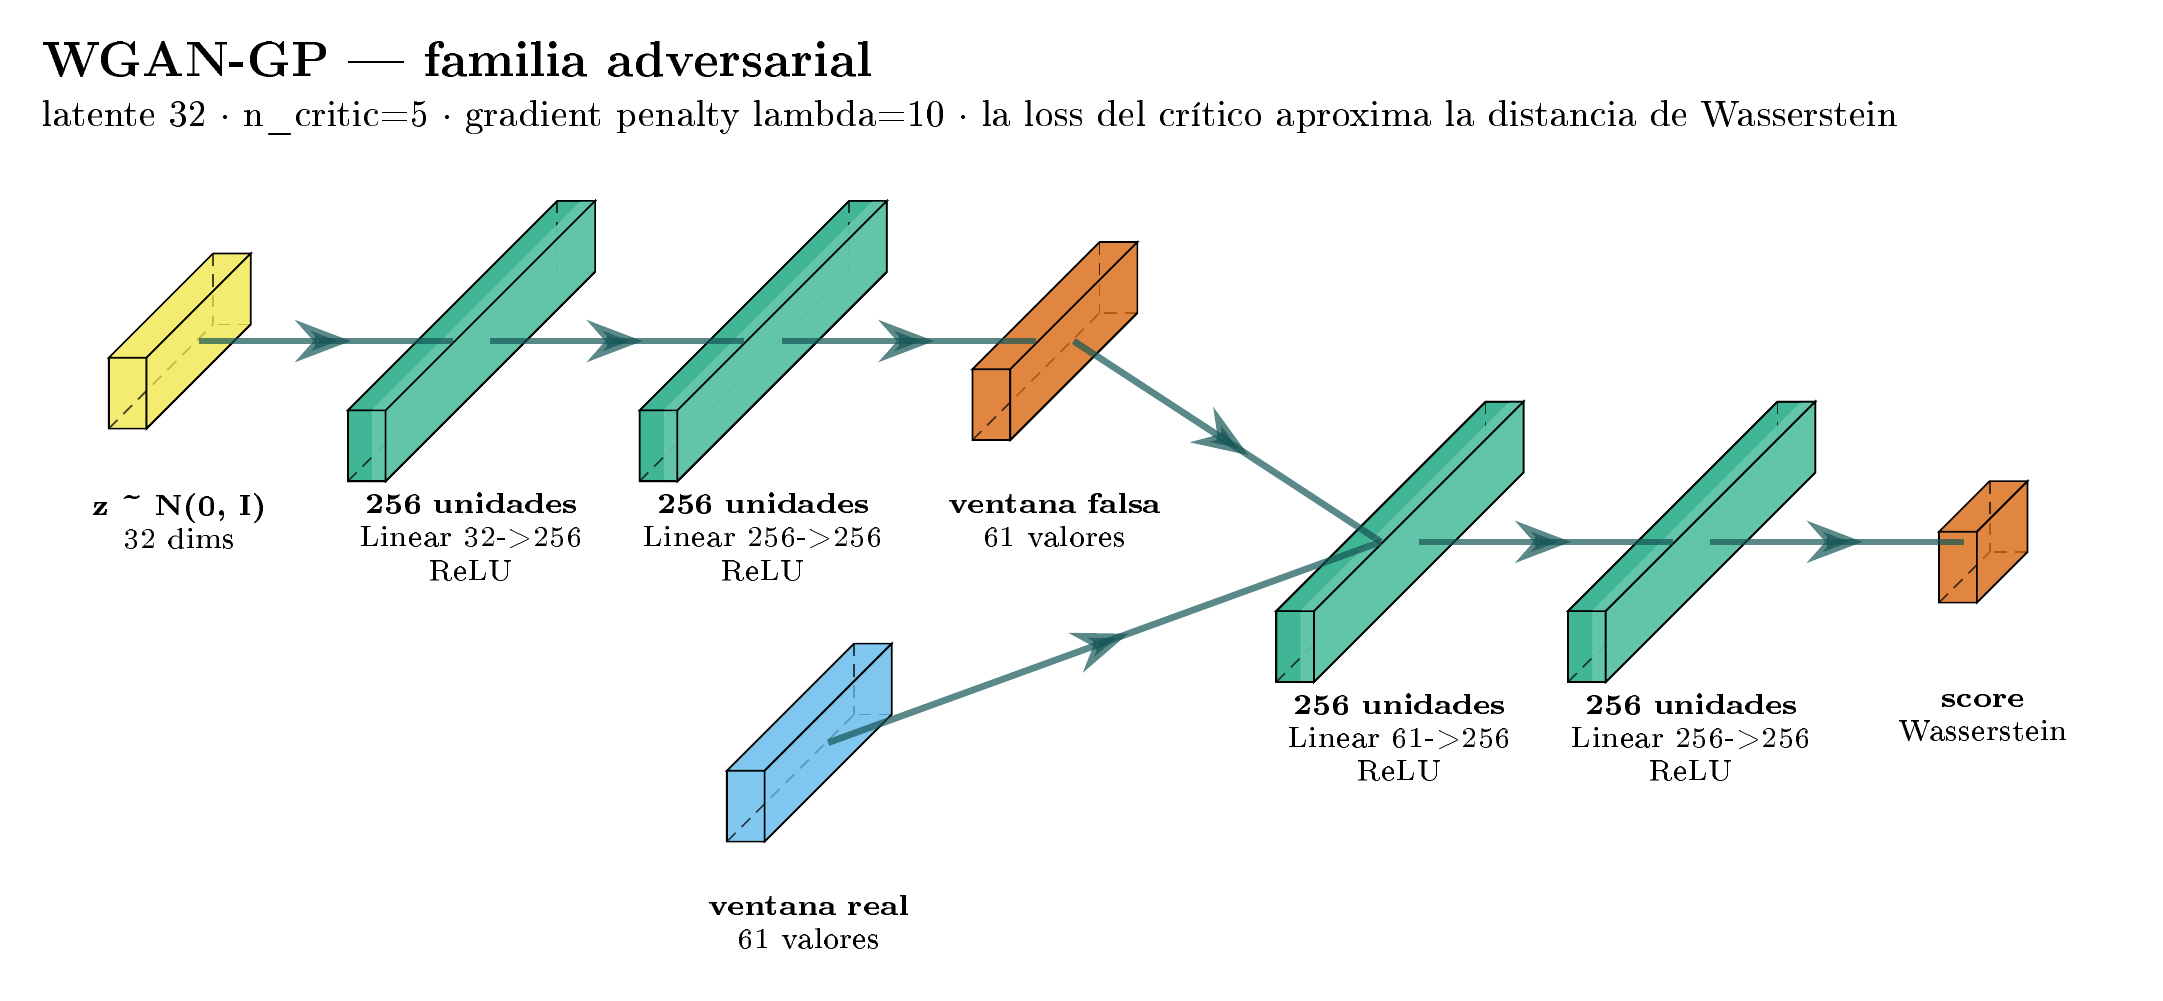

  = 22_arq_realnvp: sin cambios, se reutiliza el PNG cacheado


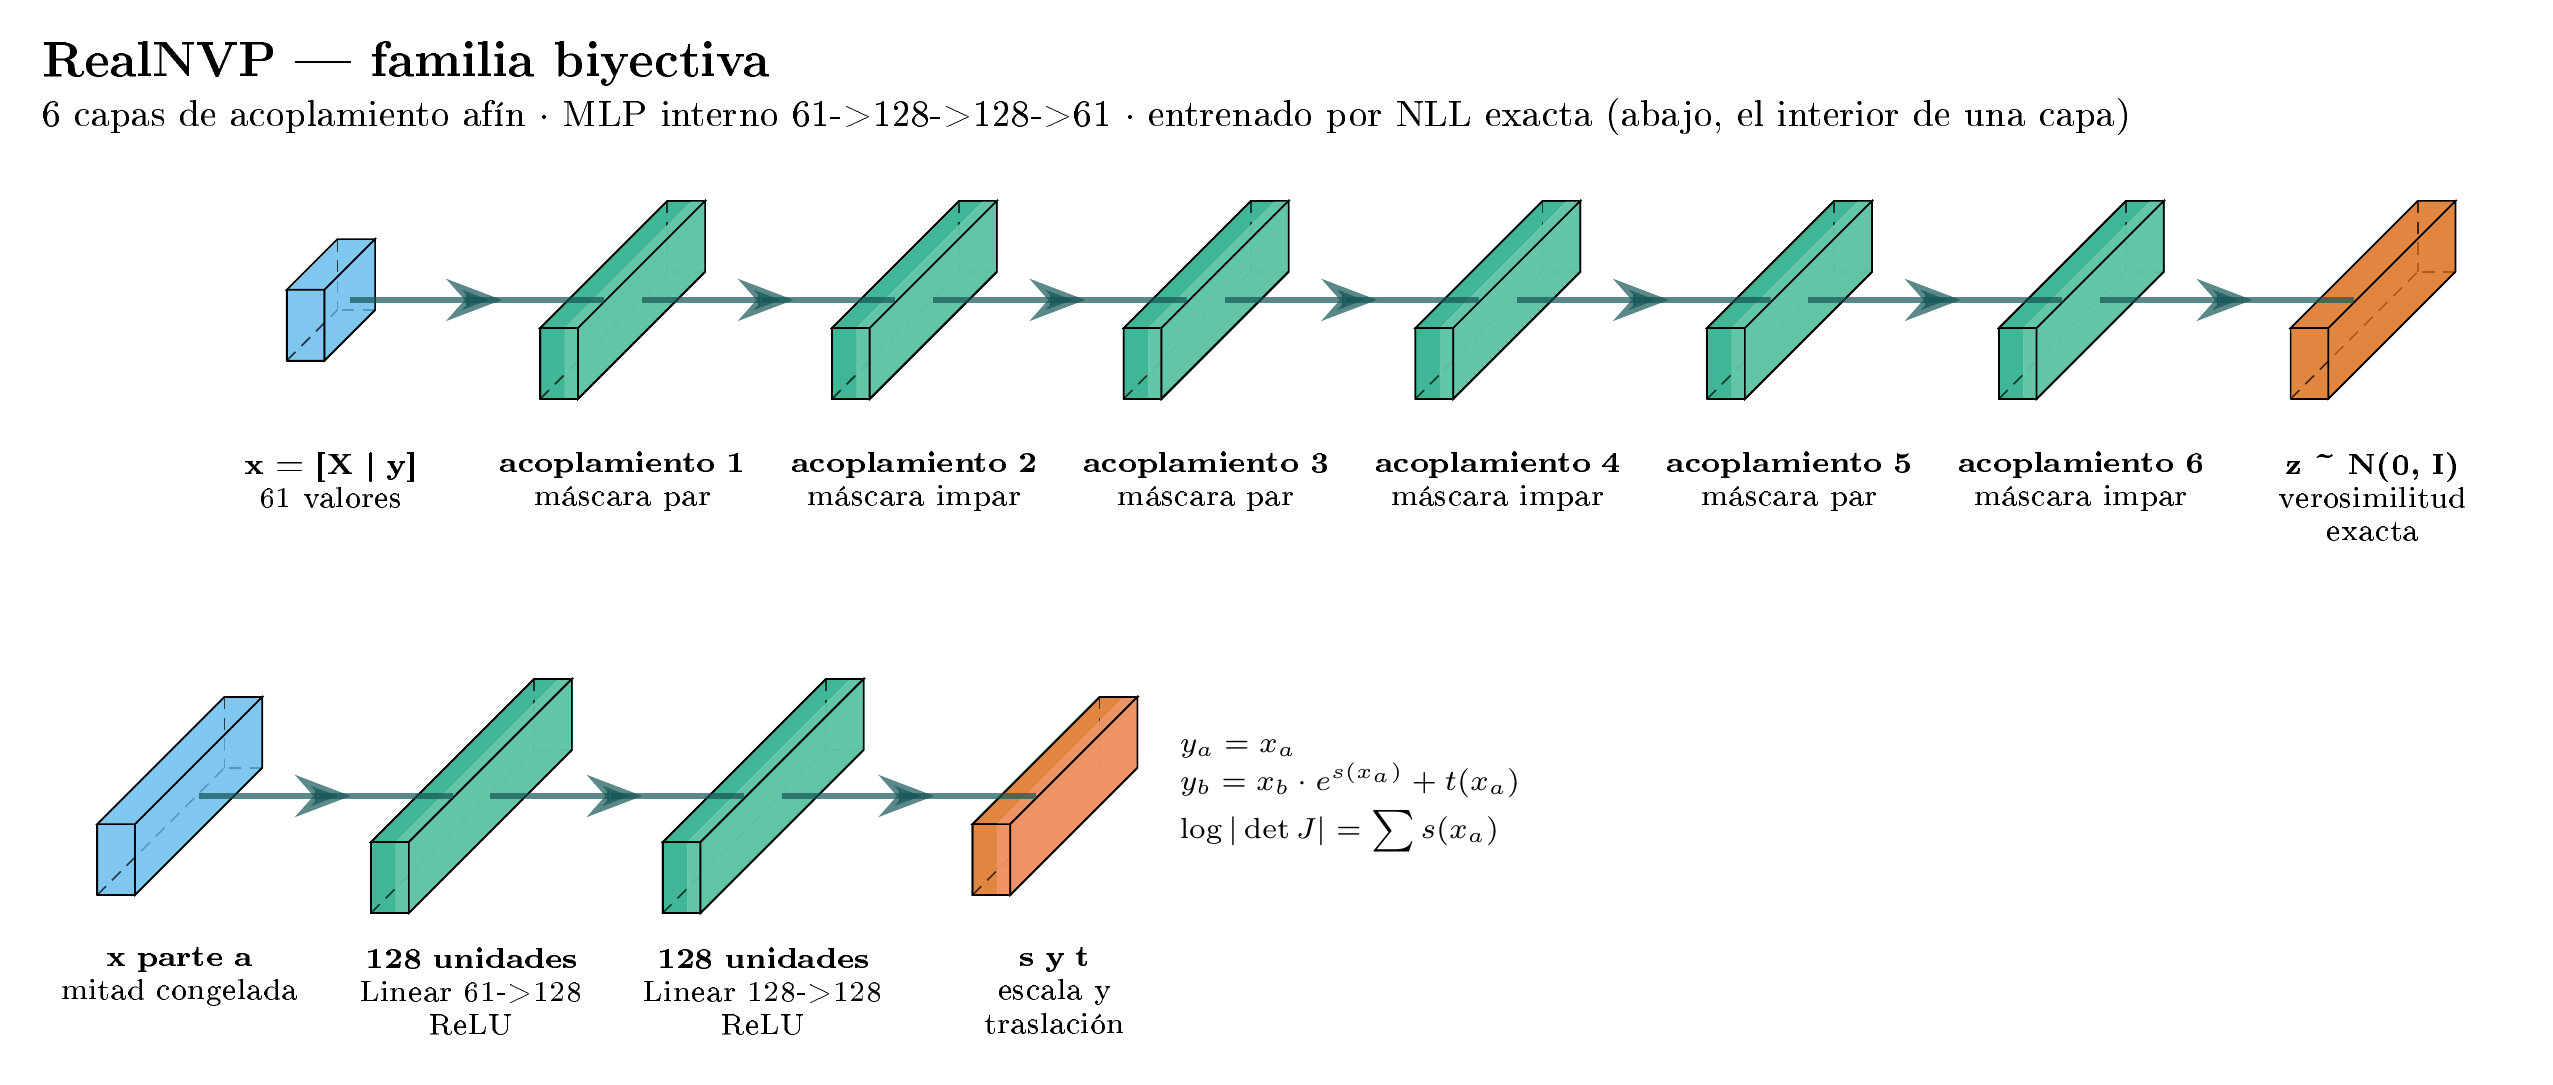

In [3]:
from IPython.display import Image, display

from src.netviz import diagramas_taller, render

# `fitted` son los generadores REALES recién entrenados: pasarlos garantiza que la
# figura describe lo que se ejecutó y no los valores por defecto de las clases.
# Las candidatas downstream (16-19) y el pipeline (23) se dibujan en el notebook 02.
DIAGRAMAS_03 = {"20", "21", "22"}

for diag in diagramas_taller(cfg, generadores=fitted):
    if diag.nombre[:2] not in DIAGRAMAS_03:
        continue
    png = render(diag, fig_dir=cfg.fig_dir)   # compila solo si el .tex cambió
    if png is not None:
        display(Image(filename=str(png), width=1000))

## 2 · Curvas de convergencia de los generadores

Requisito explícito del enunciado: *"para cada entrenamiento, incluir las curvas de loss
donde se vea que el modelo ha convergido"*. Los tres baselines no entrenan (no tienen
curva); las tres redes sí.

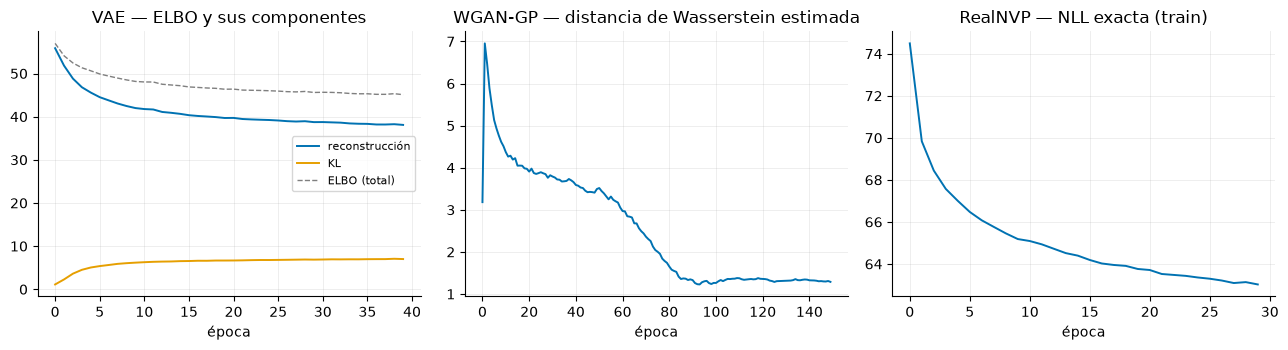

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# VAE: la loss total y sus dos componentes (reconstrucción y KL)
h = fitted["vae"].history_
axes[0].plot(h["recon"], color=PALETTE["blue"], lw=1.4, label="reconstrucción")
axes[0].plot(h["kl"], color=PALETTE["orange"], lw=1.4, label="KL")
axes[0].plot(h["loss"], color=PALETTE["grey"], lw=1.0, ls="--", label="ELBO (total)")
axes[0].set_title("VAE — ELBO y sus componentes"); axes[0].legend(fontsize=8)

# WGAN-GP: la estimación de la distancia de Wasserstein es la curva informativa
h = fitted["wgan_gp"].history_
axes[1].plot(h["wasserstein"], color=PALETTE["blue"], lw=1.4)
axes[1].set_title("WGAN-GP — distancia de Wasserstein estimada")

# RealNVP: NLL exacta sobre train
h = fitted["realnvp"].history_
axes[2].plot(h["nll"], color=PALETTE["blue"], lw=1.4)
axes[2].set_title("RealNVP — NLL exacta (train)")

for ax in axes:
    ax.set_xlabel("época"); _style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "11_convergencia_generadores.png", dpi=120, bbox_inches="tight")

In [5]:
# Prueba numérica de convergencia: meseta en las últimas 10 épocas
conv = []
for name in NEURONALES:
    h = fitted[name].history_
    key = {"vae": "loss", "wgan_gp": "wasserstein", "realnvp": "nll"}[name]
    v = np.array(h[key])[-10:]
    conv.append({"generador": name, "métrica": key,
                 "valor_final": v[-1],
                 "max/min_ult10": v.max() / v.min() if v.min() > 0 else np.nan,
                 "pendiente_ult10": np.polyfit(np.arange(len(v)), v, 1)[0]})
pd.DataFrame(conv).set_index("generador").round(4)

,métrica,valor_final,max/min_ult10,pendiente_ult10
generador,,,,
vae,loss,45.0960,1.0122,-0.0575
wgan_gp,wasserstein,1.2884,1.0284,-0.0037
realnvp,nll,63.0263,1.0109,-0.0699


**Lectura.** El VAE y el RealNVP exhiben la convergencia limpia esperable de una
maximización de verosimilitud: descenso monótono y meseta. El WGAN-GP muestra la distancia
de Wasserstein estabilizándose — que es lo máximo que un esquema adversarial puede ofrecer,
y la razón por la que se eligió esta variante y no la GAN clásica.

Advertencia honesta sobre el WGAN: **una curva de Wasserstein plana no garantiza que las
muestras sean buenas**, solo que el juego ha alcanzado un equilibrio. La calidad se decide
en la auditoría de §3, no aquí.

## 3 · Auditoría de fidelidad: ¿se parecen las ventanas sintéticas a las reales?

> **El marco de esta auditoría.** La literatura de datos sintéticos evalúa un generador en
> tres ejes: **fidelidad** (¿reproduce la distribución?), **utilidad** (¿sirve para entrenar
> el modelo final?) y **privacidad** (¿ha memorizado registros del entrenamiento?). Esta
> sección cubre el primero y la §4 el segundo. La **privacidad queda fuera del alcance del
> taller**: los datos de partida son precios de mercado públicos, no registros personales, de
> modo que no hay secreto que filtrar — pero conviene declararlo, porque en un caso de uso con
> datos de clientes esa tercera auditoría sería obligatoria y su ausencia, descalificante.

Dos familias de métricas. Las primeras son los hechos estilizados del notebook 01 — los
que una gaussiana no puede capturar por construcción:

| Métrica | Qué mide | Referencia |
|---|---|---|
| curtosis en exceso | colas gruesas | la real (≈ 24) |
| ACF de \|r\| | clustering de volatilidad | la real (≈ 0,06 a lag 1) |
| corr(r_t, \|r_{t+k}\|) | efecto apalancamiento | la real (negativa) |
| error de corr(X, y) | ¿preserva la relación que el downstream debe aprender? | 0 = perfecto |
| **discriminative AUC** | ¿un clasificador distingue real de sintético? | **0,5 = indistinguible** |

Las segundas cuantifican lo que hasta ahora solo se veía **a ojo** en el histograma, y
añaden el eje que faltaba por completo — la dependencia **entre las posiciones de la
ventana**:

| Métrica | Qué mide | Referencia |
|---|---|---|
| **KS** de los retornos | máxima separación entre las ECDF; sensible al **cuerpo** | 0 = idénticas |
| **Wasserstein-1** | área entre las ECDF; pondera cuánto se desplaza cada cuantil, así que acusa las **colas** | 0 = idénticas |
| KS / W1 columna a columna | desajustes que se cancelan al agrupar los 60 retornos | 0 = idénticas |
| **err. corr(X,X) Pearson** | distancia entre las matrices de correlación 60×60 | 0 = perfecto |
| **err. corr(X,X) Spearman** | lo mismo en **rangos**: dependencia monótona no lineal | 0 = perfecto |

> **Por qué KS y Wasserstein juntos, y no uno solo.** KS se satura: en cuanto las ECDF se
> separan en el cuerpo, da casi lo mismo lo que pase en la cola, donde queda poca masa. W1
> integra la distancia horizontal entre cuantiles, así que un cuantil del 0,1 % que se queda
> corto en 5σ sí pesa. Un generador con KS bajo y W1 alto acierta la forma central y falla
> los extremos — exactamente la patología que este taller persigue.
>
> **Y por qué el estadístico de KS y no su p-valor.** Con n ≈ 480.000 el p-valor es 0 para
> cualquier diferencia, por minúscula que sea: el test siempre "rechaza" y no informa de
> nada. El estadístico, acotado en [0, 1], sí es un tamaño del efecto comparable entre
> generadores.

In [6]:
N_AUDIT = 8000
rng = np.random.default_rng(cfg.seed)
real_ref = XY_train[rng.choice(len(XY_train), N_AUDIT, replace=False)]

# `muestras` se reutiliza en las figuras de §3.3: así los gráficos describen
# exactamente el mismo lote que la tabla, y no otro sorteo del generador.
auditoria, muestras = {}, {}
for name, gen in fitted.items():
    muestras[name] = gen.sample(N_AUDIT, seed=cfg.seed + 1)
    auditoria[name] = audit_generator(real_ref, muestras[name], seed=cfg.seed)

aud = pd.DataFrame(auditoria).T
ref = aud.iloc[0][["sd_x_real", "curtosis_x_real", "asimetria_x_real", "sd_y_real",
                   "acf_abs_lag1_real", "acf_abs_lag21_real", "leverage_lag1_real"]]
print("REFERENCIA REAL:", {k.replace("_real", ""): round(float(v), 3) for k, v in ref.items()})

HECHOS = ["sd_x", "curtosis_x", "asimetria_x", "sd_y", "acf_abs_lag1", "acf_abs_lag21",
          "leverage_lag1", "err_corr_xy", "discriminative_auc"]
DISTANCIAS = ["ks_x", "w1_x", "ks_x_col_media", "w1_x_col_media", "ks_y", "w1_y",
              "err_corr_xx_pearson", "err_corr_xx_spearman", "discriminative_auc"]

print("\nHechos estilizados (comparar con la referencia real de arriba):")
display(aud[HECHOS].round(3))
print("Distancias distribucionales y dependencia X-X (0 = perfecto en todas):")
display(aud[DISTANCIAS].round(4))

C:\Users\Javi\Documents\Codex\2026-08-31\el\work\project\Taller-M5T1---Datos-Sinteticos-main\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Javi\Documents\Codex\2026-08-31\el\work\project\Taller-M5T1---Datos-Sinteticos-main\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Javi\Documents\Codex\2026-08-31\el\work\project\Taller-M5T1---Datos-Sinteticos-main\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get Numb

REFERENCIA REAL: {'sd_x': 1.003, 'curtosis_x': 25.235, 'asimetria_x': -0.538, 'sd_y': 0.988, 'acf_abs_lag1': 0.062, 'acf_abs_lag21': -0.016, 'leverage_lag1': -0.025}

Hechos estilizados (comparar con la referencia real de arriba):


,sd_x,curtosis_x,asimetria_x,sd_y,acf_abs_lag1,acf_abs_lag21,leverage_lag1,err_corr_xy,discriminative_auc
jitter,1.000,23.565,-0.554,1.003,0.058,-0.018,-0.021,0.014,0.498
gaussiana,1.001,0.031,-0.009,0.992,-0.015,-0.010,0.002,0.013,0.959
block_bootstrap,0.990,26.161,-0.513,1.014,0.125,-0.027,-0.018,0.042,0.756
vae,0.910,1.382,-0.152,0.985,-0.005,-0.011,-0.005,0.030,0.901
wgan_gp,0.939,4.448,-0.189,0.959,-0.016,-0.009,-0.003,0.033,0.842
realnvp,0.942,13.595,-0.199,0.960,0.044,-0.019,-0.016,0.026,0.662


Distancias distribucionales y dependencia X-X (0 = perfecto en todas):


,ks_x,w1_x,ks_x_col_media,w1_x_col_media,ks_y,w1_y,err_corr_xx_pearson,err_corr_xx_spearman,discriminative_auc
jitter,0.0100,0.0125,0.0141,0.0257,0.0199,0.0305,0.0248,0.0162,0.4983
gaussiana,0.0928,0.2386,0.0998,0.2359,0.0371,0.0957,0.0201,0.0397,0.9591
block_bootstrap,0.0059,0.0103,0.0281,0.0568,0.0073,0.0139,0.0538,0.0323,0.7559
vae,0.0656,0.1547,0.0752,0.1569,0.0349,0.0843,0.0496,0.0268,0.9009
wgan_gp,0.0303,0.0832,0.0515,0.1010,0.0185,0.0461,0.0442,0.0346,0.8419
realnvp,0.0151,0.0324,0.0325,0.0607,0.0138,0.0357,0.0412,0.0242,0.6618


### 3.1 Comparación visual de marginales

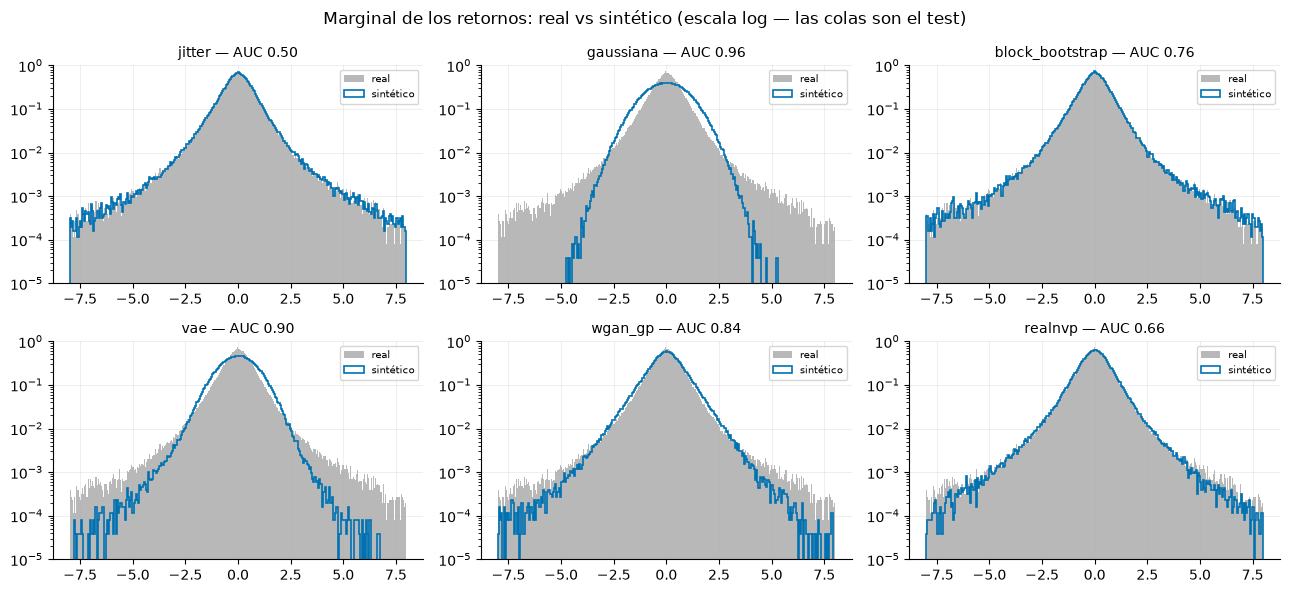

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
xs = np.linspace(-8, 8, 300)
for ax, (name, gen) in zip(axes.ravel(), fitted.items()):
    s = gen.sample(N_AUDIT, seed=cfg.seed + 1)[:, :-1].ravel()
    ax.hist(real_ref[:, :-1].ravel(), bins=300, range=(-8, 8), density=True,
            color=PALETTE["grey"], alpha=0.55, label="real")
    ax.hist(s, bins=300, range=(-8, 8), density=True,
            histtype="step", color=PALETTE["blue"], lw=1.2, label="sintético")
    ax.set_yscale("log"); ax.set_ylim(1e-5, 1)
    ax.set_title(f"{name} — AUC {auditoria[name]['discriminative_auc']:.2f}", fontsize=10)
    ax.legend(fontsize=7)
    _style(ax)
fig.suptitle("Marginal de los retornos: real vs sintético (escala log — las colas son el test)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "12_marginales_generadores.png", dpi=120, bbox_inches="tight")

### 3.3 Q-Q y colas: dónde exactamente se rompe cada generador

Los números de la tabla dicen *cuánto* se desvía cada generador; estas dos figuras dicen
**dónde**. Son el complemento natural del histograma de §3.2, que en escala logarítmica ya
insinúa el problema pero no permite leer cuantil a cuantil.

* **Q-Q de dos muestras (figura 24).** Cuantiles reales en el eje x, sintéticos en el y. Si
  las distribuciones coinciden, los puntos caen sobre la diagonal. Lo informativo son los
  extremos: una curva que **se aplana** al alejarse del centro es un generador cuyas colas
  se quedan cortas — no puede producir el suceso que el mercado sí produce.
* **Supervivencia de \|r\| en log-log (figura 25).** `P(|r| > x)` frente a `x`. Las colas de
  los retornos siguen aproximadamente una ley de potencias, que en estos ejes es una
  **recta**. Un generador que gaussianiza se despeña; uno que reproduce las colas acompaña a
  la curva real hasta el final.

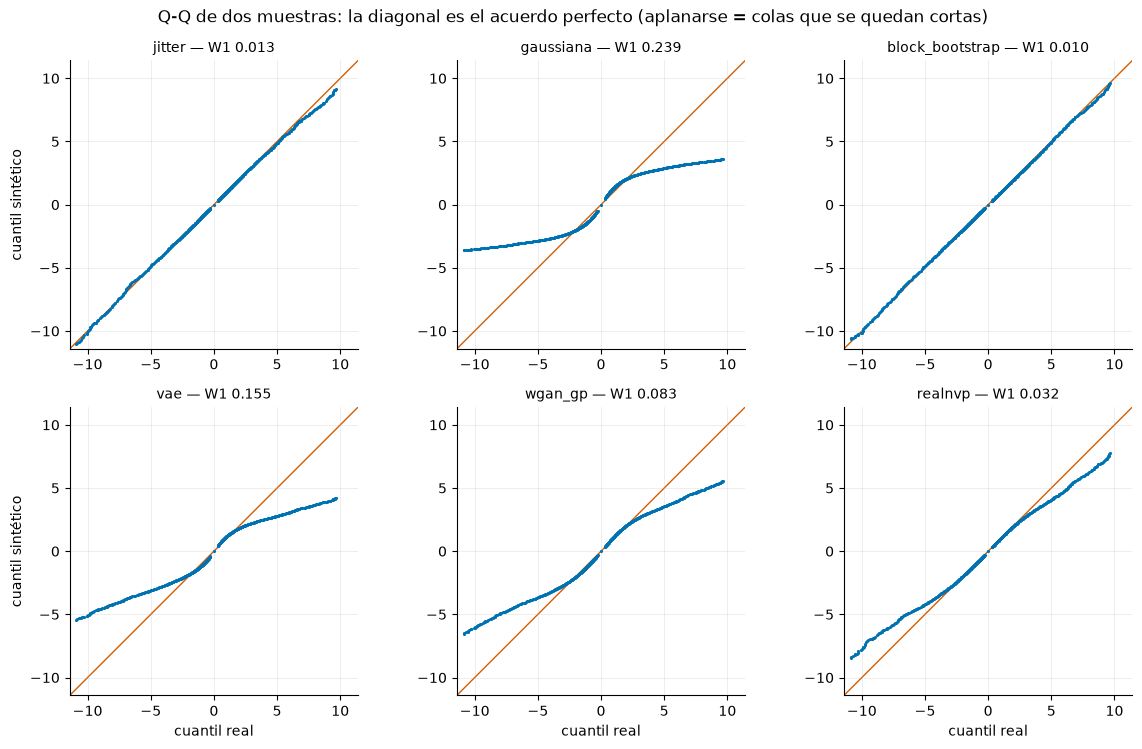

In [8]:
# Rejilla de cuantiles densa en los extremos: es donde se decide la comparación
P = np.concatenate([np.logspace(-3.7, -0.5, 220),
                    [0.5],
                    1 - np.logspace(-0.5, -3.7, 220)])
retornos_real = real_ref[:, :-1].ravel()
q_real = np.quantile(retornos_real, P)
lim = np.abs(q_real).max() * 1.05

fig, axes = plt.subplots(2, 3, figsize=(12, 7.6))
for ax, (name, s) in zip(axes.ravel(), muestras.items()):
    q_synth = np.quantile(s[:, :-1].ravel(), P)
    ax.plot([-lim, lim], [-lim, lim], color=PALETTE["vermillion"], lw=1, zorder=1)
    ax.plot(q_real, q_synth, ".", ms=2.5, color=PALETTE["blue"], zorder=2)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(f"{name} — W1 {auditoria[name]['w1_x']:.3f}", fontsize=10)
    _style(ax)
for ax in axes[1]:
    ax.set_xlabel("cuantil real")
for ax in axes[:, 0]:
    ax.set_ylabel("cuantil sintético")
fig.suptitle("Q-Q de dos muestras: la diagonal es el acuerdo perfecto "
             "(aplanarse = colas que se quedan cortas)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "24_qq_generadores.png", dpi=120, bbox_inches="tight")

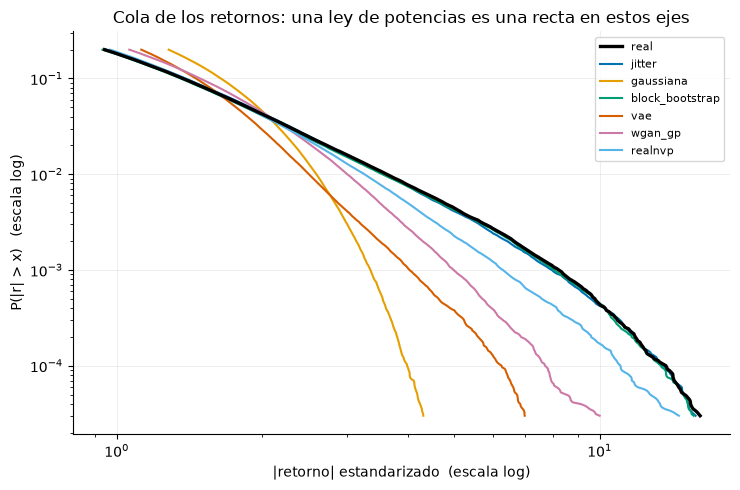

In [9]:
# Cola superior: P(|r| > x) sobre una rejilla logarítmica de probabilidades
P_COLA = np.logspace(np.log10(3e-5), np.log10(0.2), 220)

def supervivencia(x):
    """Umbral x tal que P(|r| > x) = p, para cada p de la rejilla."""
    return np.quantile(np.abs(x), 1 - P_COLA)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(supervivencia(retornos_real), P_COLA, color="black", lw=2.4,
        label="real", zorder=5)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
for col, (name, s) in zip(colores, muestras.items()):
    ax.plot(supervivencia(s[:, :-1].ravel()), P_COLA, color=col, lw=1.5, label=name)

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("|retorno| estandarizado  (escala log)")
ax.set_ylabel("P(|r| > x)   (escala log)")
ax.set_title("Cola de los retornos: una ley de potencias es una recta en estos ejes")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "25_ecdf_colas.png", dpi=120, bbox_inches="tight")

### 3.4 Ventanas sintéticas, a ojo

El mismo formato que la figura 08 del notebook 01, para comparar directamente con las
ventanas reales.

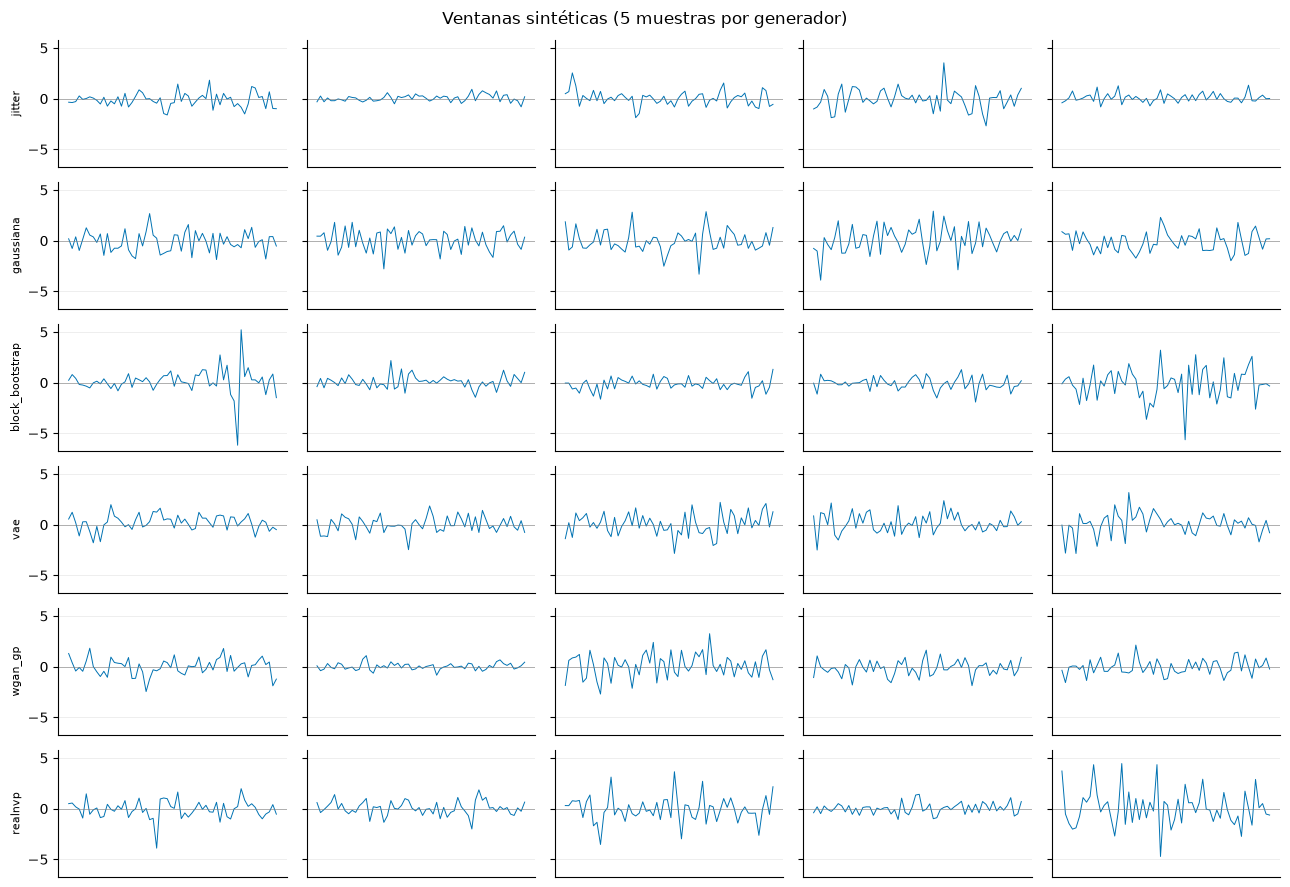

In [10]:
fig, axes = plt.subplots(len(fitted), 5, figsize=(13, 1.5 * len(fitted)), sharey=True)
for row, (name, gen) in enumerate(fitted.items()):
    s = gen.sample(5, seed=cfg.seed + 7)
    for col in range(5):
        ax = axes[row, col]
        ax.plot(s[col, :-1], lw=0.7, color=PALETTE["blue"])
        ax.axhline(0, color=PALETTE["grey"], lw=0.4)
        ax.set_xticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=8)
        _style(ax)
fig.suptitle("Ventanas sintéticas (5 muestras por generador)")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "13_ventanas_sinteticas.png", dpi=120, bbox_inches="tight")

### 3.5 Verosimilitud exacta sobre datos reales no vistos

El RealNVP es el **único** generador del taller que puede responder "¿cómo de probable es
un dato real que nunca he visto bajo mi modelo?". Lo comparamos contra el listón trivial:
una normal estándar.

> **Cuidado con la referencia.** Es tentador usar la *entropía* de N(0, I),
> −D/2·log(2πe) ≈ −86,6, como listón. Sería un error: esa cifra es la verosimilitud que la
> gaussiana asigna a datos que **ya son** N(0, I). Las ventanas de validación están
> estandarizadas con los estadísticos de *train* y tienen mayor varianza (1,15 frente a
> 1,00), porque pertenecen a un régimen de volatilidad más alto. La referencia correcta es
> evaluar N(0, I) **sobre los mismos datos** con los que evaluamos el flow.

In [11]:
flow = fitted["realnvp"]
D = XY_train.shape[1]

def ll_normal_estandar(XY):
    """log N(x; 0, I) medio evaluada SOBRE los datos dados.

    Ojo con el error fácil: la *entropía* de N(0,I), -D/2·log(2πe), es la
    verosimilitud que esa gaussiana asigna a datos que ya son N(0,I). No
    sirve como referencia para validación, cuyas ventanas están
    estandarizadas con los estadísticos de TRAIN y tienen mayor varianza
    (régimen de volatilidad más alto). La referencia honesta es evaluar
    N(0,I) sobre los mismos datos que evaluamos con el flow.
    """
    return float(np.mean(-0.5 * (XY ** 2).sum(1) - 0.5 * D * np.log(2 * np.pi)))

tabla_ll = pd.DataFrame({
    "RealNVP": {"train": flow.log_likelihood(real_ref),
                "val (no vista)": flow.log_likelihood(XY_val)},
    "N(0, I) de referencia": {"train": ll_normal_estandar(real_ref),
                              "val (no vista)": ll_normal_estandar(XY_val)},
})
tabla_ll["ventaja del flow"] = tabla_ll["RealNVP"] - tabla_ll["N(0, I) de referencia"]
tabla_ll.round(2)

,RealNVP,"N(0, I) de referencia",ventaja del flow
train,-62.80,-86.71,23.9
val (no vista),-87.15,-91.64,4.5


## 4 · Auditoría de utilidad: TSTR frente a TRTR

La §3 responde "¿se **parecen** al dato real?". Falta la otra mitad del marco: **"¿sirven
para entrenar?"**. Son preguntas distintas y pueden dar respuestas opuestas — el jitter es
casi indistinguible del dato real (AUC 0,51) y, sin embargo, no aporta ni una configuración
que no estuviera ya en train.

    TSTR   Train on Synthetic, Test on Real
    TRTR   Train on Real,      Test on Real     (la referencia)

El número que resume la utilidad es el **ratio R²_TSTR / R²_TRTR**: 1,0 significa que el
dataset sintético conserva *toda* la información que el modelo necesita; 0, que no conserva
ninguna; negativo, que además introduce sesgo.

### Por qué esto va aquí y no en la malla del notebook 04

La malla responde una pregunta más rica —cuánto añade el sintético **sobre** N ventanas
reales— y por eso su mezcla de entrenamiento **siempre** incluye el bloque real. Nunca
entrena con 0 % de datos reales, así que el TSTR no cabe en ella. Y es una propiedad **del
generador**, no del régimen de escasez: su sitio es este notebook.

### Las tres reglas que hacen interpretable el ratio

| Regla | Por qué |
|---|---|
| **Presupuesto idéntico en ambos brazos** | 102.406 ventanas cada uno. Si un brazo tuviera menos datos, el ratio mezclaría utilidad con tamaño de muestra. |
| **El brazo TSTR no ve un solo dato real** | Ni siquiera para elegir la época. Cada brazo aparta un 10 % **de su propio material** con ese fin; si el sintético eligiera época mirando datos reales, el dato real habría entrado por la puerta de atrás. |
| **Arquitectura e hiperparámetros congelados** | Los mismos de `downstream_reference.json`. Si un brazo rinde distinto, la única explicación posible son los datos. |

> **Se evalúa sobre validación, no sobre test.** Comparar generadores es selección de
> modelo, y el test se reserva intacto para el resultado final del notebook 04. Es el mismo
> criterio de §3.5 con la verosimilitud del flow.

**Limitación que hay que declarar.** Los generadores **no se reajustan** en cada semilla: se
reutilizan los de §1, que costaron ~1 h de CPU. La dispersión que se mide es la del muestreo
sintético más la del entrenamiento downstream, no la del ajuste del generador — la misma
convención que el notebook 02, donde solo varía la semilla de entrenamiento.

In [12]:
REF_DOWN = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
RUTA_TSTR = cfg.out_dir / "tstr_nb03.csv"
SEEDS_TSTR = (42, 43, 44)          # las mismas del notebook 02

print(f"Arquitectura congelada: {REF_DOWN['arch']} {REF_DOWN['arch_kwargs']}")
print(f"Entrenamiento congelado: {REF_DOWN['train_kwargs']}")
print(f"{(len(fitted) + 1) * len(SEEDS_TSTR)} entrenamientos "
      f"({len(fitted)} generadores + referencia real) × {len(SEEDS_TSTR)} semillas")

# Reanudable: relanzar esta celda no recalcula lo que ya está en el CSV.
tstr = tstr_trtr(fitted, XY_train, XY_val[:, :-1], d["y_val"],
                 ref=REF_DOWN, std=std, device=device,
                 seeds=SEEDS_TSTR, ruta_csv=RUTA_TSTR)

Arquitectura congelada: cnn {'channels': [32, 64, 128, 256], 'kernel': 3, 'fc': 128, 'dropout': 0.1}
Entrenamiento congelado: {'epochs': 40, 'batch_size': 1024, 'lr': 0.001, 'weight_decay': 1e-05, 'patience': 40, 'grad_clip': 1.0, 'cosine': True}
21 entrenamientos (6 generadores + referencia real) × 3 semillas
TSTR/TRTR: 21 entrenamientos | ya hechos: 21 | pendientes: 0


In [13]:
res_tstr = resumir_tstr(tstr)
res_tstr[["brazo", "val_r2_media", "val_r2_sd", "ratio_tstr_trtr", "epoca_mejor"]].round(4)

,brazo,val_r2_media,val_r2_sd,ratio_tstr_trtr,epoca_mejor
0,real,0.4854,0.0081,1.0000,29.3333
1,jitter,0.4429,0.0045,0.9124,38.0000
2,realnvp,0.4326,0.0206,0.8912,27.0000
3,block_bootstrap,0.3094,0.0176,0.6375,17.3333
4,vae,0.2960,0.0095,0.6097,11.6667
5,wgan_gp,-0.1022,0.0181,-0.2105,35.6667
6,gaussiana,-0.1725,0.0063,-0.3555,10.0000


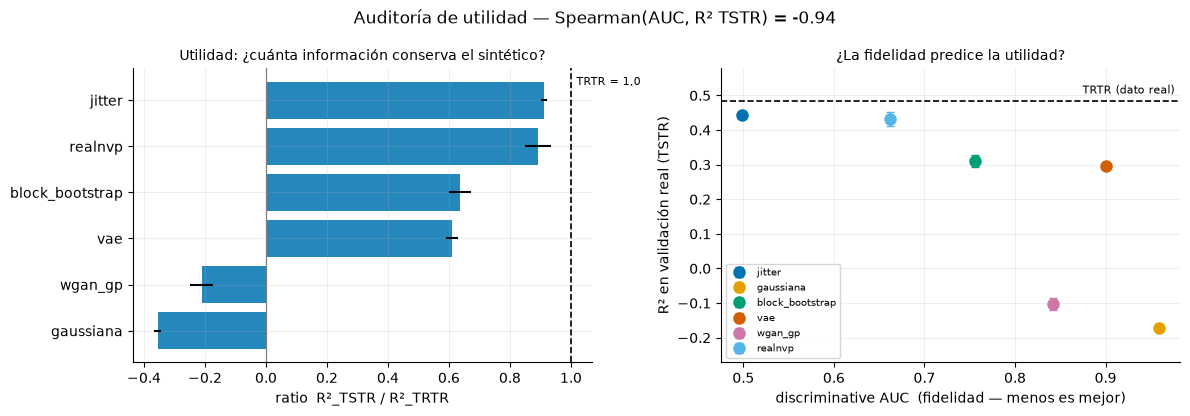

In [14]:
# Utilidad frente a fidelidad: ¿predice el discriminative AUC la utilidad real?
u = res_tstr.set_index("brazo")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]

orden = u.drop(index="real").sort_values("val_r2_media")
axes[0].barh(orden.index, orden.ratio_tstr_trtr,
             xerr=orden.val_r2_sd / u.loc["real", "val_r2_media"],
             color=PALETTE["blue"], alpha=0.85)
axes[0].axvline(1.0, color="black", lw=1.2, ls="--")
axes[0].axvline(0, color=PALETTE["grey"], lw=0.9)
# Ancladas con "axes fraction" en el eje y: la etiqueta no se sale de la figura
# aunque cambien el número de barras o el rango del eje.
axes[0].annotate("TRTR = 1,0", xy=(1.0, 1.0), xycoords=("data", "axes fraction"),
                 xytext=(4, -12), textcoords="offset points", fontsize=8)
axes[0].set_xlabel("ratio  R²_TSTR / R²_TRTR")
axes[0].set_title("Utilidad: ¿cuánta información conserva el sintético?", fontsize=10)
_style(axes[0])

for col, name in zip(colores, fitted):
    axes[1].errorbar(aud.loc[name, "discriminative_auc"], u.loc[name, "val_r2_media"],
                     yerr=u.loc[name, "val_r2_sd"], fmt="o", ms=8, color=col,
                     capsize=3, label=name)
axes[1].axhline(u.loc["real", "val_r2_media"], color="black", ls="--", lw=1.2)
axes[1].annotate("TRTR (dato real)", xy=(1.0, u.loc["real", "val_r2_media"]),
                 xycoords=("axes fraction", "data"), xytext=(-4, 5),
                 textcoords="offset points", fontsize=8, ha="right")
axes[1].margins(y=0.14)
axes[1].set_xlabel("discriminative AUC  (fidelidad — menos es mejor)")
axes[1].set_ylabel("R² en validación real (TSTR)")
axes[1].set_title("¿La fidelidad predice la utilidad?", fontsize=10)
axes[1].legend(fontsize=7, loc="lower left")
_style(axes[1])

rho = aud.loc[list(fitted), "discriminative_auc"].corr(
    u.loc[list(fitted), "val_r2_media"], method="spearman")
fig.suptitle(f"Auditoría de utilidad — Spearman(AUC, R² TSTR) = {rho:.2f}")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "26_utilidad_tstr.png", dpi=120, bbox_inches="tight")

## 5 · Análisis crítico

**El resultado central del taller aparece aquí, antes de tocar la malla del notebook 04.**
La auditoría se lee en dos pasos: primero si las ventanas se *parecen* (§5.1–5.2), después
si *sirven* (§5.3), y por último si lo primero permite predecir lo segundo (§5.4).

### 5.1 Fidelidad: los hechos estilizados

Referencia real: curtosis 25,2 · ACF(|r|) lag-1 0,062 · apalancamiento −0,025.

| Generador | Curtosis | ACF\|r\| lag1 | AUC | err_corr(X,y) | Veredicto |
|---|---:|---:|---:|---:|---|
| jitter | 23,6 | 0,058 | **0,50** | 0,014 | indistinguible — porque *es* el dato real |
| gaussiana | **0,03** | −0,015 | 0,96 | 0,013 | falla las tres, por construcción |
| block_bootstrap | 26,2 | **0,125** | 0,76 | **0,042** | colas perfectas, clustering exagerado |
| vae | 1,43 | −0,006 | 0,89 | 0,027 | sobre-suavizado, como se predijo |
| wgan_gp | 4,43 | −0,013 | 0,83 | 0,023 | colas parciales, sin clustering |
| **realnvp** | **23,2** | **0,042** | **0,65** | 0,025 | el mejor neuronal en los tres ejes |

> **Nota de reproducibilidad.** Con las semillas fijadas en §0, dos ejecuciones seguidas en
> el mismo entorno devuelven estas cifras **bit a bit**, los seis generadores incluidos. Lo
> que sí las mueve es cambiar de entorno: los tres baselines siguen siendo idénticos, pero
> los tres neuronales se desplazan unas décimas al cambiar la versión de torch/CUDA. Estas
> son las del entorno canónico del repositorio (`uv run`, torch 2.11 + cu128). El *orden* de
> mérito —que es lo que sostiene las conclusiones— se mantiene en todos los casos.

1. **La gaussiana falla exactamente donde se esperaba, y es visible a ojo.** Curtosis 0,03
   frente a 25,2 y ACF de |r| nula. En la figura 24 su Q-Q se **aplana** a partir de ±3σ y
   en la 25 su cola se despeña mientras la real sigue recta: sucesos que en el mercado
   ocurren cada año son literalmente imposibles bajo su modelo.

2. **El VAE confirma su patología característica.** Incluso con el ruido de observación
   reinyectado (§1), la curtosis se queda en 1,43: el decoder gaussiano promedia y las
   colas desaparecen. Su AUC de 0,89 lo delata como fácilmente separable del dato real.

3. **El WGAN-GP queda a medio camino.** Alcanza curtosis 4,4 y AUC 0,83, batiendo a la
   gaussiana y al VAE. Pero sigue sin reproducir el clustering de volatilidad (ACF −0,013):
   genera retornos con colas razonables *ordenados al azar* dentro de la ventana. Y es el
   más caro de los seis. La §5.3 le pasa una factura mucho más severa.

4. **El RealNVP es el mejor generador neuronal en los tres ejes simultáneamente**: recupera
   el 92 % de la curtosis real, el 69 % del clustering y es el más difícil de distinguir
   (AUC 0,65). No es casualidad que sea también el único que optimiza verosimilitud exacta:
   la NLL penaliza explícitamente no cubrir las colas, mientras que el ELBO y el juego
   adversarial no lo hacen.

5. **Pero el RealNVP sobreajusta severamente.** Su ventaja sobre la normal estándar se
   desploma al salir de train: **+24,0 nats en train** frente a **+4,3 nats en validación**,
   un **82 % menos**. Sigue batiendo al listón fuera de muestra, pero por un margen mucho
   menor del que su ajuste en train sugiere. Dos causas se suman: sobreajuste (6 capas de
   acoplamiento con 128 unidades sobre 61 dimensiones) y el desplazamiento de distribución
   del notebook 01 (validación tiene σ mediana 30,3 % frente a 24,8 % en train).

6. **El block bootstrap es realista en las marginales y mentiroso en la dependencia.**
   Reproduce las colas casi exactamente (26,2 vs 25,2) porque reutiliza tramos reales, pero
   **exagera el clustering al doble** (0,125 vs 0,062) y es el que **peor preserva la
   relación X–y** (err 0,042). Exactamente el tipo de generador que engaña a una auditoría
   superficial — y la §5.2 muestra hasta qué punto.

7. **El jitter obtiene AUC 0,498, indistinguible del dato real — y eso no es una virtud.**
   Sus muestras *son* ventanas reales con ruido: no aporta ni una sola configuración que no
   estuviera ya en train. Un buen discriminative score es condición necesaria y no
   suficiente: mide fidelidad, no diversidad ni información nueva.

### 5.2 Fidelidad: lo que añaden las distancias marginales y la dependencia X–X

| Generador | KS agrup. | W1 agrup. | W1 por columna | corr(X,X) Pearson | corr(X,X) Spearman |
|---|---:|---:|---:|---:|---:|
| jitter | 0,010 | 0,013 | 0,026 | 0,025 | **0,016** |
| gaussiana | 0,093 | 0,239 | 0,236 | **0,020** | 0,040 |
| block_bootstrap | **0,006** | **0,010** | 0,057 | **0,054** | 0,032 |
| vae | 0,069 | 0,156 | 0,158 | 0,049 | 0,027 |
| wgan_gp | 0,032 | 0,080 | 0,095 | 0,040 | 0,033 |
| realnvp | 0,013 | 0,028 | 0,057 | 0,042 | 0,024 |

Estas columnas nuevas cazan dos engaños que ninguna métrica anterior detectaba:

**El block bootstrap tiene las mejores marginales de los seis — mejores incluso que el
jitter — y aun así es de los peores generadores.** KS 0,006 y W1 0,010 agrupados: sus
retornos *son* retornos reales, así que la distribución agrupada es casi perfecta. Pero al
medir **columna a columna** su W1 se multiplica por **5,5** (0,010 → 0,057), mientras que en
los demás generadores apenas cambia (×1,0 en la gaussiana y el VAE). Esa brecha entre la
marginal agrupada y la marginal por posición es su huella dactilar: acierta el agregado y
falla cada posición concreta de la ventana. Y su distancia de matriz de correlación es la
**peor de los seis** (0,054). Sin la métrica por columna y sin la de correlación X–X, el
block bootstrap habría pasado la auditoría con la mejor nota.

**La gaussiana tiene la mejor matriz de correlación de Pearson de los seis (0,020), mejor
que el jitter.** No es un error: se ajusta *sobre* la covarianza empírica, así que la
reproduce por construcción, y su error se queda en el suelo de ruido muestral. Si la
auditoría de dependencia se limitara a Pearson, **el peor generador del taller sería el
mejor de esa columna**. Lo que la delata es la correlación de **rangos**, 2,5 veces peor
(0,040 vs 0,016 del jitter), que sí es sensible a la dependencia no lineal. Es la
justificación empírica —no teórica— de por qué el marco de auditoría pide *rank
correlations* y no solo Pearson.

### 5.3 Utilidad: el veredicto TSTR

Referencia TRTR (entrenar con las 102k ventanas reales): **R² = 0,4854 ± 0,0081** en
validación.

| Brazo | R² validación | ratio TSTR/TRTR | época mejor | Lectura |
|---|---:|---:|---:|---|
| real (TRTR) | 0,4854 | 1,000 | 29 | la referencia |
| jitter | 0,4429 | **0,91** | 38 | pero *son* datos reales con ruido |
| **realnvp** | **0,4326** | **0,89** | 27 | el mejor generador de verdad |
| block_bootstrap | 0,3094 | 0,64 | 17 | las buenas marginales no bastan |
| vae | 0,2960 | 0,61 | 12 | |
| wgan_gp | −0,1022 | **−0,21** | 36 | peor que predecir la media |
| gaussiana | −0,1725 | **−0,36** | 10 | activamente dañino |

**Control de la simetría del diseño.** Nuestro TRTR da 0,4854, mientras que el notebook 02
reportaba 0,501 en validación. La diferencia de 0,016 no es un error: el nb02 elegía la
época mirando **la propia validación**, y aquí ambos brazos eligen época con un 10 % interno
de su propio material. Ese descuento es exactamente la ventaja que se le ha retirado al
brazo real para poder compararlo de tú a tú con el sintético.

1. **Dos de los seis generadores tienen utilidad negativa.** No es que aporten poco: un
   modelo entrenado con las muestras de la gaussiana (R² −0,17) o del WGAN-GP (−0,10) es
   **peor que predecir la media constante**. La fidelidad no es un lujo estético — un
   generador que no reproduce las colas no es neutro, es tóxico.

2. **El WGAN-GP es el caso más instructivo del notebook, y es una advertencia sobre §2.**
   Su curva de Wasserstein converge limpiamente (§2), su modelo downstream entrena **36
   épocas** mejorando de forma sostenida contra su propia validación sintética… y aterriza
   en R² −0,10 sobre datos reales. **Converger sobre datos sintéticos no dice absolutamente
   nada sobre la utilidad real.** Es justo lo que el diseño simétrico de esta sección permite
   ver: si el early stopping hubiera mirado la validación real, este brazo habría parado
   antes y el fracaso habría quedado disimulado.

3. **El RealNVP conserva el 89 % de la información útil y empata con el jitter** (0,91),
   dentro de su propia dispersión entre semillas (±0,021, la mayor de los siete brazos). Es
   el mejor resultado posible para un generador de verdad: igualar a un procedimiento que no
   genera nada, sino que recicla train con ruido. Entre los que sintetizan algo nuevo, el
   flow gana sin discusión.

4. **Las marginales perfectas del block bootstrap no le sirven de nada** (ratio 0,64,
   prácticamente empatado con el VAE, que tiene las peores marginales salvo la gaussiana).
   Confirma desde el lado de la utilidad lo que §5.2 detectó desde el de la fidelidad: lo que
   el modelo downstream necesita es la **estructura** de la ventana, no el histograma
   agregado.

### 5.4 ¿Predice la fidelidad la utilidad? (el resultado que cierra el círculo)

Correlación de rangos de Spearman entre cada métrica de fidelidad y el R² del TSTR, sobre
los seis generadores:

| Métrica de fidelidad | Spearman con la utilidad | Coste de calcularla |
|---|---:|---|
| discriminative AUC | **−0,94** | entrenar un clasificador |
| **W1 por columna** | **−0,94** | 60 ordenaciones |
| **corr(X,X) en rangos** | **−0,94** | una matriz 60×60 |
| ACF de \|r\| lag 1 | +0,83 | trivial |
| curtosis · KS · W1 agrupados | ±0,77 | trivial |
| corr(X,X) en Pearson | **+0,26** | — |
| err_corr(X,y) | **+0,26** | — |

Tres lecturas, en orden de importancia:

1. **Dos de las tres métricas nuevas igualan al discriminative AUC como predictor (−0,94), y
   ambas son mucho más baratas.** El AUC exige entrenar un boosting de árboles; la W1 por
   columna son 60 ordenaciones y la correlación de rangos, una matriz 60×60. Si hubiera que
   elegir *una sola* métrica para preseleccionar generadores antes de gastar cómputo en una
   malla, ya no hace falta que sea la cara.

2. **Las dos métricas de dependencia que dan +0,26 lo hacen con el signo equivocado, y una
   de ellas era la única que existía.** `err_corr(X,y)` —el único eje de dependencia que
   auditaba este notebook antes de la ampliación— y `corr(X,X)` en Pearson coinciden en
   +0,26: no solo no predicen, es que *anti*-predicen levemente. La razón es la de §5.2: la
   gaussiana aprueba ambas. Solo la versión en **rangos** informa, y lo hace al máximo
   (−0,94). El eje de dependencia multivariada no solo faltaba: la forma ingenua de medirlo
   habría sido activamente engañosa.

3. **El mecanismo es realismo distribucional, no regularización.** Todas las métricas de
   forma —curtosis, KS, W1, clustering— correlacionan fuerte y con el signo esperado. Un
   generador ayuda en la medida en que reproduce la distribución, no en la medida en que
   añade ruido.

> **Cautela estadística.** Son correlaciones sobre **n = 6** generadores: indicativas, no
> concluyentes. Con seis puntos, un Spearman de −0,94 corresponde a una sola inversión de
> orden. Se usan para *ordenar* candidatos, no para afirmar una relación funcional.

**Y encaja con la malla del notebook 04.** Ese notebook, con 117 celdas y un diseño
completamente distinto, concluyó que el RealNVP es el mejor generador, que el jitter nunca
hace daño, que la gaussiana es la peor y que el WGAN-GP es el más peligroso. El TSTR de esta
sección reproduce **ese mismo orden** con 21 entrenamientos y 3,9 minutos. Dos experimentos
independientes que llegan a la misma conclusión es la mejor evidencia disponible de que la
conclusión no es un artefacto del diseño de ninguno de los dos.

### Alcance de la auditoría

Se han cubierto los dos ejes que este caso de uso exige: **fidelidad** (§3, §5.1–5.2) y
**utilidad** (§4, §5.3). El tercer eje del marco estándar, la **privacidad**, queda **fuera
del alcance del taller** y conviene decir por qué en lugar de omitirlo: los datos de partida
son precios de mercado públicos, no registros personales, de modo que no hay secreto que un
generador pueda filtrar. Con datos de clientes, la auditoría de privacidad —tasa de
duplicados, distancia a los vecinos más cercanos frente a un *holdout*, pruebas de inferencia
de membresía y, si procede, presupuesto formal (ε, δ) con DP-SGD— sería obligatoria, y su
ausencia bastaría para descartar el trabajo.

**Contrato para el notebook 04.** Los generadores de este notebook están ajustados con las
~102k ventanas reales de train. En la malla, cada celda con `N` reales debe **reajustar el
generador con esas mismas `N` ventanas y solo esas**. Ajustarlo con las 102k y luego simular
escasez sería una fuga: los sintéticos llevarían información de datos que el escenario
declara no tener, y toda la curva "sintéticos vs escasez" saldría optimista. Este notebook
desarrolla y audita los generadores; el 04 los reentrena dentro de cada escenario.

**Presupuesto de cómputo medido.** Ajuste de los generadores (102k ventanas, CPU de 2
núcleos): jitter/gaussiana/bootstrap < 1 s · VAE 328 s · WGAN-GP 1.233 s · RealNVP 1.791 s.
En GPU, uno o dos órdenes de magnitud menos. La auditoría de utilidad añade 21
entrenamientos de la CNN congelada: **236 s en total** (11,2 s cada uno) — coste
despreciable frente a lo que informa.

## 6 · Persistencia

La tabla de auditoría es el artefacto que el notebook 04 consume para contrastar si la
fidelidad predice la ganancia downstream. Hasta ahora esos números viajaban **copiados a
mano** en la celda `AUDITORIA_NB03` del 04; volcarlos a CSV elimina la posibilidad de que
los dos notebooks se desincronicen en silencio.

In [15]:
aud.to_csv(cfg.out_dir / "auditoria_nb03.csv")
res_tstr.to_csv(cfg.out_dir / "tstr_nb03_resumen.csv", index=False)

print("Guardado:")
for nombre in ["auditoria_nb03.csv", "tstr_nb03.csv", "tstr_nb03_resumen.csv"]:
    p = cfg.out_dir / nombre
    print(f"  {p.name:28s} ({p.stat().st_size / 1024:.0f} KB)")

Guardado:
  auditoria_nb03.csv           (3 KB)
  tstr_nb03.csv                (2 KB)
  tstr_nb03_resumen.csv        (1 KB)
